## Validate the model using the Analog retrieval benchmark.

In [54]:
import torch
import torch.nn as nn
import yaml
import argparse
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader
import copy

In [55]:
# --- 1. SETUP PATHS ---
cwd = Path.cwd()
cwd = cwd.parents[1]

In [56]:
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(cwd, "train_test_scripts"))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [57]:
try:
    from classifier_siamesemodel_new import SiameseSpectralSimilarityModel
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
except ImportError as e:
    print(f"Error importing modules: {e}")
    sys.exit(1)

In [58]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [59]:
# --- CONFIGURATION ---
CONFIG = {
    'test_pairs_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather',
    'spec_data_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl',
    'mol_data_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl',
    'template_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/template.yml',  
    'custom_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml',      
    
    # UPDATE THESE TWO PATHS:
    'binary_model_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/binary_classifier/focal_loss_models/best_focal_model.pth',     
    'checkpoint_path': '/data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl', 
    
    'output_dir': './results/benchmarks',
    'gpu_id': 0,
    'num_decoys': 50,      
    'num_queries': 500, # Set to -1 to run full test set
    'batch_size': 32    # Inference batch size
}

In [65]:
def run_retrieval_benchmark():
    args = argparse.Namespace(**CONFIG)
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    os.makedirs(args.output_dir, exist_ok=True)
    
    print(f"--- Starting Analog Retrieval Benchmark ---")
    
    # 1. LOAD MAIN DATASET
    print("Loading Dataset (Heavy Lift)...")
    main_dataset = BinaryClassificationDataset(
        args.test_pairs_path, 
        args.spec_data_path, 
        args.mol_data_path
    )
    
    # Determine the attribute name for the internal dataframe
    # Your class uses 'self.pairs_df' based on the provided code
    dataset_df_attr = 'pairs_df'
    
    print(f"Dataset initialized. Internal DF attribute: '{dataset_df_attr}'")

    # 2. IDENTIFY QUERY PAIRS
    print("Selecting Query Pairs...")
    full_df = pd.read_feather(args.test_pairs_path)
    true_pairs = full_df[full_df['label'] == 1.0].reset_index(drop=True)
    
    if args.num_queries > 0 and args.num_queries < len(true_pairs):
        true_pairs = true_pairs.sample(n=args.num_queries, random_state=42).reset_index(drop=True)
    
    print(f"Evaluating on {len(true_pairs)} queries.")
    
    # FIX: Use .spec_lookup instead of .spec_df
    # Your dataloader sets self.spec_lookup = spec_df.set_index('spec_id')
    all_spec_ids = list(main_dataset.spec_lookup.index)

    # 3. INITIALIZE MODEL
    print("Initializing Model...")
    with open(args.template_config_path, 'r') as f: t_conf = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: c_conf = yaml.safe_load(f)
    full_config = merge_configs(t_conf, c_conf)
    
    # Dynamically check meta dim
    try:
        sample_item = main_dataset[0]
        # item is (A, B, meta, mass, label)
        # Meta shape is [1, dim] (unsqueeze(0) in dataloader)
        spec_meta_dim = sample_item[2].shape[1] 
    except:
        spec_meta_dim = 68 # Fallback

    model = SiameseSpectralSimilarityModel(
        model_config=full_config.get('model', {}),
        checkpoint_path=args.checkpoint_path, 
        spec_meta_dim=spec_meta_dim
    ).to(device)

    print(f"Loading trained weights from {args.binary_model_path}")
    state = torch.load(args.binary_model_path, map_location=device)
    if 'state_dict' in state: state = state['state_dict']
    elif 'best_model_sd' in state: state = state['best_model_sd']
    
    new_state = {}
    for k, v in state.items():
        k = k.replace('module.', '')
        new_state[k] = v
    model.load_state_dict(new_state)
    model.eval()

    # 4. BENCHMARK LOOP
    ranks = []
    
    print("Running Inference Loop...")
    for idx, row in tqdm(true_pairs.iterrows(), total=len(true_pairs)):
        anchor_id = row['name_main']
        true_target_id = row['name_sub']
        
        # Validation: Ensure IDs exist in lookup
        if anchor_id not in main_dataset.spec_lookup.index or true_target_id not in main_dataset.spec_lookup.index:
            continue

        # A. Generate Decoys
        candidates = [true_target_id]
        while len(candidates) < args.num_decoys + 1:
            draws = np.random.choice(all_spec_ids, size=args.num_decoys, replace=False)
            for d in draws:
                if d != anchor_id and d != true_target_id and d not in candidates:
                    # Double check if decoy exists in lookup
                    if d in main_dataset.spec_lookup.index:
                        candidates.append(d)
                        if len(candidates) >= args.num_decoys + 1:
                            break
        
        # B. Create "Synthetic" Dataframe for this Query
        # We construct a dataframe that looks exactly like the input feather file
        # Columns: name_main, name_sub, label
        query_df = pd.DataFrame({
            'name_main': [anchor_id] * len(candidates),
            'name_sub': candidates,
            'label': [1.0] + [0.0] * args.num_decoys
        })
        
        # C. INJECT into Dataset
        # "Hot-swapping" the dataframe allows us to use the dataloader's exact logic
        setattr(main_dataset, dataset_df_attr, query_df)
        
        # D. Run Inference
        loader = DataLoader(
            main_dataset,
            batch_size=args.batch_size,
            shuffle=False, 
            collate_fn=binary_collate_fn,
            num_workers=0 
        )
        
        batch_scores = []
        
        try:
            with torch.no_grad():
                for batch_A, batch_B, batch_meta, mass_diffs, _ in loader:
                    # Move to GPU
                    # Batch graphs are dictionaries in MassFormer
                    for k in batch_A: batch_A[k] = batch_A[k].to(device)
                    for k in batch_B: batch_B[k] = batch_B[k].to(device)
                    batch_meta = batch_meta.to(device)
                    mass_diffs = mass_diffs.to(device)
                    
                    logits = model(batch_A, batch_B, batch_meta, mass_diffs).view(-1)
                    probs = torch.sigmoid(logits)
                    batch_scores.extend(probs.cpu().numpy())
            
            # E. Calculate Rank
            target_score = batch_scores[0]
            # Rank = 1 + (Number of decoys with score > target)
            rank = np.sum(np.array(batch_scores) > target_score) + 1
            ranks.append(rank)
            
        except Exception as e:
            # print(f"Error on query {idx}: {e}")
            continue

    # 5. METRICS & PLOT
    if not ranks:
        print("CRITICAL: No queries completed successfully.")
        return

    ranks = np.array(ranks)
    top1 = np.mean(ranks == 1)
    top3 = np.mean(ranks <= 3)
    top10 = np.mean(ranks <= 10)
    mrr = np.mean(1.0 / ranks)
    
    print("\n" + "="*40)
    print("   ANALOG RETRIEVAL RESULTS")
    print("="*40)
    print(f"Top-1 Accuracy: {top1:.2%}")
    print(f"Top-3 Accuracy: {top3:.2%}")
    print(f"Top-10 Accuracy: {top10:.2%}")
    print(f"Mean Reciprocal Rank: {mrr:.3f}")
    
    plt.figure(figsize=(10, 6))
    plt.hist(ranks, bins=range(1, args.num_decoys+3), align='left', rwidth=0.8, color='#4CAF50')
    plt.axvline(1, color='red', linestyle='--', label='Perfect Rank')
    plt.title(f"Retrieval Rank Distribution (Top-1: {top1:.1%})")
    plt.xlabel("Rank of True Analog")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    save_path = os.path.join(args.output_dir, 'retrieval_benchmark_final.png')
    plt.savefig(save_path)
    print(f"Plot saved to {save_path}")

--- Starting Analog Retrieval Benchmark ---
Loading Dataset (Heavy Lift)...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Dataset initialized. Internal DF attribute: 'pairs_df'
Selecting Query Pairs...
Evaluating on 500 queries.
Initializing Model...
Loading encoder weights from /data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Siamese Model Initialized (Decoupled Architecture).
  - Head Input Dim: 82
  - Mass Gating Active
Loading trained weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/binary_classifier/focal_loss_models/best_focal_model.pth
Running Inference Loop...


100%|██████████| 500/500 [09:48<00:00,  1.18s/it]



   ANALOG RETRIEVAL RESULTS
Top-1 Accuracy: 77.40%
Top-3 Accuracy: 87.40%
Top-10 Accuracy: 94.20%
Mean Reciprocal Rank: 0.837
Plot saved to ./results/benchmarks/retrieval_benchmark_final.png


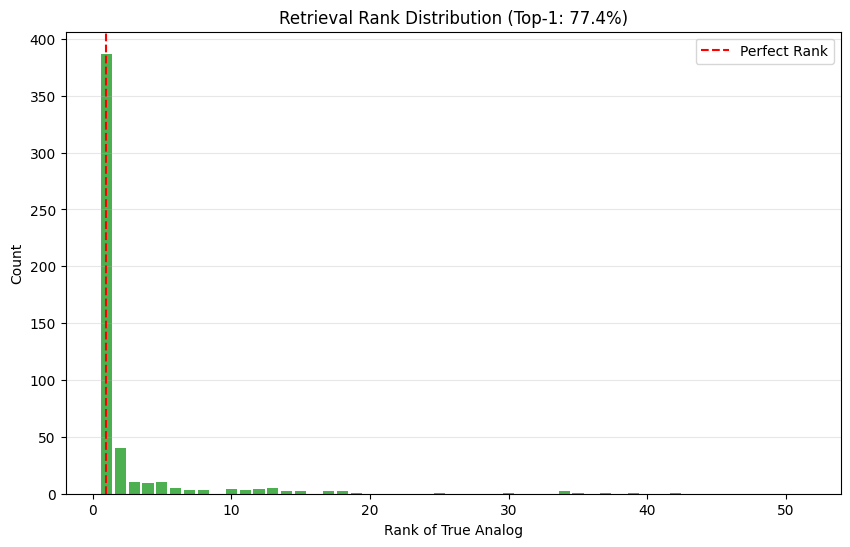

In [66]:
run_retrieval_benchmark()

## Visualize the analog rankings

In [67]:
import torch
import yaml
import argparse
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader

In [68]:
# --- 1. SETUP PATHS ---
cwd = Path.cwd()
cwd = cwd.parents[1]

In [69]:
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(cwd, "train_test_scripts"))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [70]:
try:
    from classifier_siamesemodel_new import SiameseSpectralSimilarityModel
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
except ImportError as e:
    print(f"Error importing modules: {e}")
    sys.exit(1)

In [71]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [ ]:
# --- CONFIGURATION ---
CONFIG = {
    'test_pairs_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather',
    'spec_data_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl',
    'mol_data_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl',
    'template_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/template.yml',  
    'custom_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml',      
    
    # UPDATE THESE TWO PATHS:
    'binary_model_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/binary_classifier/focal_loss_models/best_focal_model.pth',     
    'checkpoint_path': '/data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl', 
    
    'output_dir': './results/benchmarks',
    'gpu_id': 0,
    'num_decoys': 50,      
    'num_queries': 500, # Set to -1 to run full test set
    'examples_to_find': 3, # Generate 2 Successes and 2 Failures
    'batch_size': 32    # Inference batch size
}

In [86]:
def plot_spectrum(ax, peaks, title, color='blue', highlight=False):
    """ Helper to plot a single MS spectrum """
    if peaks is None or len(peaks) == 0:
        ax.text(0.5, 0.5, "Empty Spectrum", ha='center')
        return

    mzs, ints = zip(*peaks)
    mzs = np.array(mzs)
    ints = np.array(ints)
    if ints.max() > 0: ints = ints / ints.max() * 100.0
    
    ax.vlines(mzs, 0, ints, color=color, linewidth=1.5 if highlight else 1)
    ax.set_ylim(0, 115)
    ax.set_xlim(0, max(mzs) + 50)
    ax.set_title(title, fontsize=10, fontweight='bold' if highlight else 'normal', color=color)
    ax.set_ylabel("Rel. Int.")
    ax.grid(axis='x', alpha=0.3)

In [88]:
def create_comparison_plot(anchor_id, true_target_id, sorted_cands, rank, case_type, dataset, out_dir, idx):
    # Data Retrieval
    anchor_peaks = dataset.spec_lookup.loc[anchor_id]['peaks']
    
    # 1. Rank 1 Candidate (Model's Choice)
    rank1_id, rank1_score = sorted_cands[0]
    rank1_peaks = dataset.spec_lookup.loc[rank1_id]['peaks']
    
    # 2. True Target (Ground Truth)
    target_score = [s for c,s in sorted_cands if c == true_target_id][0]
    target_peaks = dataset.spec_lookup.loc[true_target_id]['peaks']
    
    # Setup Plot
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    plt.subplots_adjust(hspace=0.4)
    
    # Plot 1: Anchor
    plot_spectrum(axes[0], anchor_peaks, f"ANCHOR (Query)\nID: {anchor_id}", color='black', highlight=True)
    
    # Plot 2: Rank 1 (Model's Choice)
    is_correct = (rank1_id == true_target_id)
    color = 'green' if is_correct else 'red'
    status = "CORRECT (True Analog)" if is_correct else "INCORRECT (Decoy)"
    plot_spectrum(axes[1], rank1_peaks, f"MODEL RANK #1: {status}\nScore: {rank1_score:.4f} | ID: {rank1_id}", color=color, highlight=is_correct)
    
    # Plot 3: Ground Truth
    # If Rank 1 was correct, this duplicates Row 2 but reinforces the point.
    # If Rank 1 was wrong, this shows what the model MISSED.
    plot_spectrum(axes[2], target_peaks, f"GROUND TRUTH (True Analog)\nActual Rank: #{rank} | Score: {target_score:.4f} | ID: {true_target_id}", color='green', highlight=True)
    
    axes[-1].set_xlabel("m/z")
    
    filename = f"{case_type}_Rank{rank}_Query{idx}.png"
    plt.savefig(os.path.join(out_dir, filename), dpi=150, bbox_inches='tight')
    plt.close()
    print(f" Saved visualization: {filename}")

In [90]:
def visualize_rankings():
    args = argparse.Namespace(**CONFIG)
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    os.makedirs(args.output_dir, exist_ok=True)
    
    # --- LOAD DATA ---
    print("Loading Dataset...")
    dataset = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    
    # Force load spec_df if not loaded
    if not hasattr(dataset, 'spec_lookup'):
        spec_df = pd.read_pickle(args.spec_data_path)
        dataset.spec_lookup = spec_df.set_index('spec_id')

    # Detect Internal DF Attribute Name
    dataset_df_attr = 'pairs_df'
    if hasattr(dataset, 'df'): dataset_df_attr = 'df'
    elif hasattr(dataset, 'data'): dataset_df_attr = 'data'

    all_spec_ids = list(dataset.spec_lookup.index)
    
    full_df = pd.read_feather(args.test_pairs_path)
    true_pairs = full_df[full_df['label'] == 1.0].sample(n=200, random_state=42).reset_index(drop=True)

    # --- LOAD MODEL ---
    print("Loading Model...")
    with open(args.template_config_path, 'r') as f: t_conf = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: c_conf = yaml.safe_load(f)
    full_config = merge_configs(t_conf, c_conf)
    
    try:
        spec_meta_dim = dataset[0][2].shape[1]
    except:
        spec_meta_dim = 68 

    model = SiameseSpectralSimilarityModel(
        model_config=full_config.get('model', {}),
        checkpoint_path=args.checkpoint_path, 
        spec_meta_dim=spec_meta_dim
    ).to(device)

    state = torch.load(args.binary_model_path, map_location=device)
    state = state.get('state_dict', state)
    state = {k.replace('module.', ''): v for k, v in state.items()}
    model.load_state_dict(state)
    model.eval()

    # --- SEARCH LOOP ---
    successes_found = 0
    failures_found = 0
    
    print("Searching for interesting cases...")
    
    for idx, row in tqdm(true_pairs.iterrows(), total=len(true_pairs)):
        if successes_found >= args.examples_to_find and failures_found >= args.examples_to_find:
            break
            
        anchor_id = row['name_main']
        true_target_id = row['name_sub']
        
        if anchor_id not in dataset.spec_lookup.index or true_target_id not in dataset.spec_lookup.index: 
            continue

        candidates = [true_target_id]
        while len(candidates) < args.num_decoys + 1:
            d = np.random.choice(all_spec_ids)
            if d != anchor_id and d != true_target_id and d not in candidates:
                if d in dataset.spec_lookup.index: candidates.append(d)

        query_df = pd.DataFrame({
            'name_main': [anchor_id] * len(candidates),
            'name_sub': candidates,
            'label': [1.0] + [0.0] * args.num_decoys
        })
        
        setattr(dataset, dataset_df_attr, query_df)
        loader = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=binary_collate_fn, num_workers=0)
        
        batch_scores = []
        try:
            with torch.no_grad():
                for b in loader:
                    b = [x.to(device) if isinstance(x, torch.Tensor) else x for x in b]
                    if not isinstance(b[0], torch.Tensor): 
                         for k in b[0]: b[0][k] = b[0][k].to(device)
                         for k in b[1]: b[1][k] = b[1][k].to(device)
                    logits = model(b[0], b[1], b[2], b[3]).view(-1)
                    batch_scores.extend(torch.sigmoid(logits).cpu().numpy())
        except: continue

        # Rank Analysis
        scored_candidates = list(zip(candidates, batch_scores))
        sorted_candidates = sorted(scored_candidates, key=lambda x: x[1], reverse=True)
        
        rank = -1
        for r, (cid, score) in enumerate(sorted_candidates):
            if cid == true_target_id:
                rank = r + 1
                break
        
        case_type = None
        if rank == 1 and successes_found < args.examples_to_find:
            case_type = "Success"
            successes_found += 1
        elif rank > 5 and failures_found < args.examples_to_find:
            case_type = "Failure"
            failures_found += 1
        
        if case_type:
            create_comparison_plot(anchor_id, true_target_id, sorted_candidates, rank, case_type, dataset, args.output_dir, idx)

In [91]:
visualize_rankings()

Loading Dataset...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Loading Model...
Loading encoder weights from /data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Siamese Model Initialized (Decoupled Architecture).
  - Head Input Dim: 82
  - Mass Gating Active
Searching for interesting cases...


  1%|          | 2/200 [00:04<07:49,  2.37s/it]

 Saved visualization: Success_Rank1_Query1.png


...

 Saved visualization: Failure_Rank11_Query2.png


  2%|▏         | 4/200 [00:09<07:34,  2.32s/it]

 Saved visualization: Success_Rank1_Query3.png


  8%|▊         | 16/200 [00:34<06:34,  2.14s/it]

 Saved visualization: Failure_Rank12_Query15.png


## Benchmark on honest data regime

In [92]:
import torch
import yaml
import argparse
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader
import bisect # For efficient mass range searching

In [93]:
# --- 1. SETUP PATHS ---
cwd = Path.cwd()
cwd = cwd.parents[1]

In [94]:
cwd

PosixPath('/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor')

In [95]:
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(cwd, "train_test_scripts"))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [ ]:
try:
    from classifier_siamesemodel_new import SiameseSpectralSimilarityModel
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
except ImportError as e:
    print(f"Error importing modules: {e}")
    sys.exit(1)

Adding /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/train_test_scripts/validate_model/data_loaders to sys.path
Adding /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/train_test_scripts/validate_model/model to sys.path
Parent directory: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor
Adding /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/tmach007/massformer/src/massformer to sys.path
Parent directory: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor
Adding /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/tmach007/massformer/src/massformer to sys.path
Current working directory: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/train_test_scripts/validate_model
Parent directory: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor
Adding /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/tmach007/massformer/src/massformer to sys.path


In [97]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [98]:
# --- CONFIGURATION ---
STRICT_CONFIG = {
    'test_pairs_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather',
    'spec_data_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl',
    'mol_data_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl',
    'template_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/template.yml',  
    'custom_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml',      
    'binary_model_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/binary_classifier/focal_loss_models/best_focal_model.pth',     
    'checkpoint_path': '/data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl', 
    'output_dir': './results/benchmarks_strict',
    'gpu_id': 0,
    
    # --- STRICT SETTINGS ---
    'num_decoys': 50,      
    'num_queries': 500,    
    'batch_size': 32,
    
    # BOTH Targets AND Decoys must respect these bounds relative to Anchor
    'min_mass_diff': 1.0,   
    'max_mass_diff': 100.0  
}

In [99]:
def run_strict_benchmark():
    args = argparse.Namespace(**STRICT_CONFIG)
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    os.makedirs(args.output_dir, exist_ok=True)
    
    print(f"--- Starting STRICT HONEST ZONE Benchmark ---")
    print(f"Constraint: Targets AND Decoys must be in range [{args.min_mass_diff}, {args.max_mass_diff}] Da")
    
    # 1. LOAD DATA
    print("Loading Dataset...")
    main_dataset = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    
    if not hasattr(main_dataset, 'spec_lookup'):
        spec_df = pd.read_pickle(args.spec_data_path)
        main_dataset.spec_lookup = spec_df.set_index('spec_id')
    
    dataset_df_attr = 'pairs_df'
    if hasattr(main_dataset, 'df'): dataset_df_attr = 'df'
    elif hasattr(main_dataset, 'data'): dataset_df_attr = 'data'

    # 2. PRE-PROCESS MASS INDEX (For Fast Decoy Lookup)
    print("Building Mass Index...")
    # Extract list of (mass, id) tuples
    # We drop NaNs to avoid errors
    spec_data = main_dataset.spec_lookup[['prec_mz']].dropna().reset_index()
    # Sort by mass for binary search
    sorted_specs = spec_data.sort_values('prec_mz')
    
    all_masses = sorted_specs['prec_mz'].values
    all_ids = sorted_specs['spec_id'].values
    
    print(f"Indexed {len(all_masses)} spectra by mass.")

    # 3. FILTER QUERIES (True Pair Constraint)
    full_df = pd.read_feather(args.test_pairs_path)
    positive_pairs = full_df[full_df['label'] == 1.0].reset_index(drop=True)
    
    honest_indices = []
    print("Filtering queries for Honest Zone...")
    for idx, row in tqdm(positive_pairs.iterrows(), total=len(positive_pairs)):
        id_A, id_B = row['name_main'], row['name_sub']
        if id_A not in main_dataset.spec_lookup.index or id_B not in main_dataset.spec_lookup.index: continue
        
        mass_A = main_dataset.spec_lookup.loc[id_A]['prec_mz']
        mass_B = main_dataset.spec_lookup.loc[id_B]['prec_mz']
        
        if args.min_mass_diff <= abs(mass_A - mass_B) <= args.max_mass_diff:
            honest_indices.append(idx)
            
    query_pairs = positive_pairs.iloc[honest_indices].reset_index(drop=True)
    if args.num_queries > 0 and args.num_queries < len(query_pairs):
        query_pairs = query_pairs.sample(n=args.num_queries, random_state=42).reset_index(drop=True)
        
    print(f"Selected {len(query_pairs)} Strict Honest Queries.")

    # 4. MODEL SETUP
    with open(args.template_config_path, 'r') as f: t_conf = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: c_conf = yaml.safe_load(f)
    full_config = merge_configs(t_conf, c_conf)
    
    try: spec_meta_dim = main_dataset[0][2].shape[1]
    except: spec_meta_dim = 68 

    model = SiameseSpectralSimilarityModel(
        model_config=full_config.get('model', {}),
        checkpoint_path=args.checkpoint_path, 
        spec_meta_dim=spec_meta_dim
    ).to(device)

    state = torch.load(args.binary_model_path, map_location=device)
    state = state.get('state_dict', state)
    state = {k.replace('module.', ''): v for k, v in state.items()}
    model.load_state_dict(state)
    model.eval()

    # 5. BENCHMARK LOOP
    ranks = []
    valid_queries = 0
    
    for idx, row in tqdm(query_pairs.iterrows(), total=len(query_pairs)):
        anchor_id = row['name_main']
        true_target_id = row['name_sub']
        
        anchor_mass = main_dataset.spec_lookup.loc[anchor_id]['prec_mz']
        
        # --- STRICT DECOY SAMPLING ---
        # We need decoys D such that:
        # (Mass_A - 100) <= Mass_D <= (Mass_A - 1)  OR  (Mass_A + 1) <= Mass_D <= (Mass_A + 100)
        
        # Define ranges
        low_min, low_max = anchor_mass - args.max_mass_diff, anchor_mass - args.min_mass_diff
        high_min, high_max = anchor_mass + args.min_mass_diff, anchor_mass + args.max_mass_diff
        
        # Use binary search to find indices in sorted array
        # Range 1: [low_min, low_max]
        idx_l_start = bisect.bisect_left(all_masses, low_min)
        idx_l_end = bisect.bisect_right(all_masses, low_max)
        
        # Range 2: [high_min, high_max]
        idx_h_start = bisect.bisect_left(all_masses, high_min)
        idx_h_end = bisect.bisect_right(all_masses, high_max)
        
        # Collect Candidate Indices
        valid_indices = list(range(idx_l_start, idx_l_end)) + list(range(idx_h_start, idx_h_end))
        
        # If not enough valid decoys exist in the honest zone, skip this query
        if len(valid_indices) < args.num_decoys:
            # Optional: Log this if too many get skipped
            continue
            
        # Get IDs from indices
        potential_decoys = all_ids[valid_indices]
        
        # Filter: Exclude Anchor and True Target
        potential_decoys = [d for d in potential_decoys if d != anchor_id and d != true_target_id]
        
        if len(potential_decoys) < args.num_decoys:
            continue
            
        # Randomly sample strictly valid decoys
        decoys = np.random.choice(potential_decoys, size=args.num_decoys, replace=False).tolist()
        
        # Form Candidate List
        candidates = [true_target_id] + decoys
        
        # --- INFERENCE ---
        query_df = pd.DataFrame({
            'name_main': [anchor_id] * len(candidates),
            'name_sub': candidates,
            'label': [1.0] + [0.0] * args.num_decoys
        })
        
        setattr(main_dataset, dataset_df_attr, query_df)
        loader = DataLoader(main_dataset, batch_size=args.batch_size, shuffle=False, collate_fn=binary_collate_fn, num_workers=0)
        
        batch_scores = []
        try:
            with torch.no_grad():
                for b in loader:
                    b = [x.to(device) if isinstance(x, torch.Tensor) else x for x in b]
                    if not isinstance(b[0], torch.Tensor): 
                         for k in b[0]: b[0][k] = b[0][k].to(device)
                         for k in b[1]: b[1][k] = b[1][k].to(device)
                    logits = model(b[0], b[1], b[2], b[3]).view(-1)
                    batch_scores.extend(torch.sigmoid(logits).cpu().numpy())
        except: continue

        target_score = batch_scores[0]
        rank = np.sum(np.array(batch_scores) > target_score) + 1
        ranks.append(rank)
        valid_queries += 1

    # 6. RESULTS
    if len(ranks) == 0:
        print("No valid queries completed.")
        return

    ranks = np.array(ranks)
    top1 = np.mean(ranks == 1)
    top3 = np.mean(ranks <= 3)
    top10 = np.mean(ranks <= 10)
    mrr = np.mean(1.0 / ranks)
    
    print("\n" + "="*40)
    print(f"   STRICT HONEST ZONE RESULTS (N={valid_queries})")
    print("="*40)
    print(f"Top-1 Accuracy: {top1:.2%}")
    print(f"Top-3 Accuracy: {top3:.2%}")
    print(f"Top-10 Accuracy: {top10:.2%}")
    print(f"Mean Reciprocal Rank: {mrr:.3f}")
    
    plt.figure(figsize=(10, 6))
    plt.hist(ranks, bins=range(1, args.num_decoys+3), align='left', rwidth=0.8, color='orange', edgecolor='black')
    plt.axvline(1, color='red', linestyle='--', label='Perfect Rank')
    plt.title(f"Strict Honest Retrieval (Top-1: {top1:.1%})\n(All candidates within 1-100 Da of Anchor)")
    plt.xlabel("Rank of True Analog")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    save_path = os.path.join(args.output_dir, 'strict_honest_benchmark.png')
    plt.savefig(save_path)
    print(f"Plot saved to {save_path}")

--- Starting STRICT HONEST ZONE Benchmark ---
Constraint: Targets AND Decoys must be in range [1.0, 100.0] Da
Loading Dataset...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Building Mass Index...
Indexed 227308 spectra by mass.
Filtering queries for Honest Zone...


100%|██████████| 2429/2429 [00:00<00:00, 6234.99it/s]


Selected 500 Strict Honest Queries.
Loading encoder weights from /data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Siamese Model Initialized (Decoupled Architecture).
  - Head Input Dim: 82
  - Mass Gating Active


100%|██████████| 500/500 [04:16<00:00,  1.95it/s]



   STRICT HONEST ZONE RESULTS (N=500)
Top-1 Accuracy: 73.80%
Top-3 Accuracy: 85.60%
Top-10 Accuracy: 92.80%
Mean Reciprocal Rank: 0.808
Plot saved to ./results/benchmarks_strict/strict_honest_benchmark.png


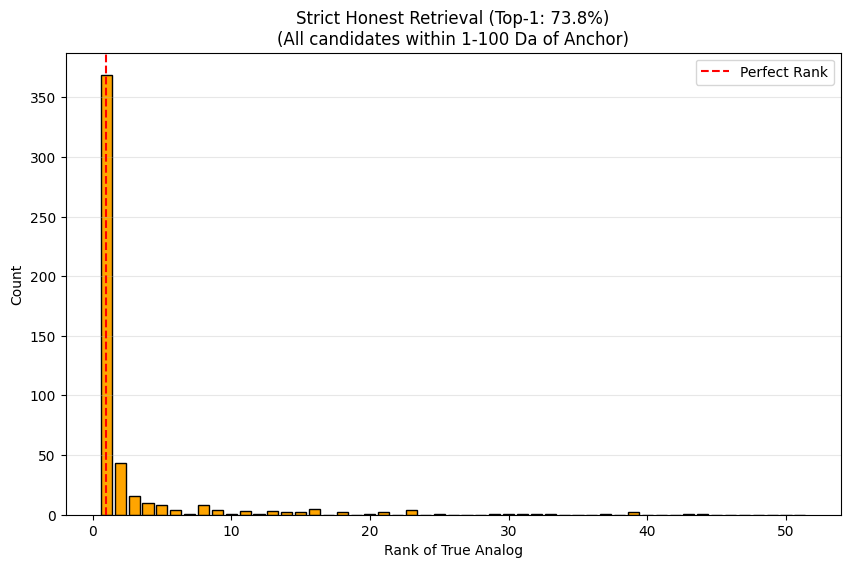

In [100]:
run_strict_benchmark()

## Visualize ranking in the honest data regime

In [101]:
import torch
import yaml
import argparse
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader
import bisect

In [102]:
# --- 1. SETUP PATHS ---
cwd = Path.cwd()
cwd = cwd.parents[1]

In [103]:
cwd

PosixPath('/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor')

In [104]:
try:
    from classifier_siamesemodel_new import SiameseSpectralSimilarityModel
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
except ImportError as e:
    print(f"Error importing modules: {e}")
    sys.exit(1)

In [105]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [ ]:
# --- CONFIGURATION ---
STRICT_CONFIG = {
    'test_pairs_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather',
    'spec_data_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl',
    'mol_data_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl',
    'template_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/template.yml',  
    'custom_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml',      
    'binary_model_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/binary_classifier/focal_loss_models/best_focal_model.pth',     
    'checkpoint_path': '/data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl', 
    'output_dir': './results/benchmarks_strict',
    'gpu_id': 0,
    
    # --- STRICT SETTINGS ---
    'num_decoys': 50,      
    'num_queries': 500,    
    'batch_size': 32,
    'examples_to_find': 3,
    
    # BOTH Targets AND Decoys must respect these bounds relative to Anchor
    'min_mass_diff': 1.0,   
    'max_mass_diff': 100.0  
}

In [113]:
def plot_spectrum(ax, peaks, title, color='blue', highlight=False):
    if peaks is None or len(peaks) == 0:
        ax.text(0.5, 0.5, "Empty Spectrum", ha='center')
        return

    mzs, ints = zip(*peaks)
    mzs = np.array(mzs)
    ints = np.array(ints)
    if ints.max() > 0: ints = ints / ints.max() * 100.0
    
    ax.vlines(mzs, 0, ints, color=color, linewidth=1.5 if highlight else 1)
    ax.set_ylim(0, 115)
    ax.set_xlim(0, max(mzs) + 50)
    ax.set_title(title, fontsize=10, fontweight='bold' if highlight else 'normal', color=color)
    ax.set_ylabel("Rel. Int.")
    ax.grid(axis='x', alpha=0.3)

In [114]:
def create_comparison_plot(anchor_id, true_target_id, sorted_cands, rank, case_type, dataset, out_dir, idx):
    anchor_peaks = dataset.spec_lookup.loc[anchor_id]['peaks']
    
    # 1. Rank 1 Candidate
    rank1_id, rank1_score = sorted_cands[0]
    rank1_peaks = dataset.spec_lookup.loc[rank1_id]['peaks']
    
    # 2. True Target
    target_score = [s for c,s in sorted_cands if c == true_target_id][0]
    target_peaks = dataset.spec_lookup.loc[true_target_id]['peaks']
    
    # Calculate Mass Diffs for Title
    mass_A = dataset.spec_lookup.loc[anchor_id]['prec_mz']
    mass_R1 = dataset.spec_lookup.loc[rank1_id]['prec_mz']
    mass_T = dataset.spec_lookup.loc[true_target_id]['prec_mz']
    diff_R1 = abs(mass_A - mass_R1)
    diff_T = abs(mass_A - mass_T)

    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    plt.subplots_adjust(hspace=0.4)
    
    plot_spectrum(axes[0], anchor_peaks, f"ANCHOR (Query)\nID: {anchor_id} | Mass: {mass_A:.2f}", color='black', highlight=True)
    
    is_correct = (rank1_id == true_target_id)
    color = 'green' if is_correct else 'red'
    status = "CORRECT (True Analog)" if is_correct else "INCORRECT (Decoy)"
    plot_spectrum(axes[1], rank1_peaks, f"MODEL RANK #1: {status}\nScore: {rank1_score:.4f} | ΔMass: {diff_R1:.2f} Da | ID: {rank1_id}", color=color, highlight=is_correct)
    
    plot_spectrum(axes[2], target_peaks, f"GROUND TRUTH (True Analog)\nActual Rank: #{rank} | Score: {target_score:.4f} | ΔMass: {diff_T:.2f} Da | ID: {true_target_id}", color='green', highlight=True)
    
    axes[-1].set_xlabel("m/z")
    filename = f"{case_type}_Rank{rank}_Query{idx}.png"
    plt.savefig(os.path.join(out_dir, filename), dpi=150, bbox_inches='tight')
    plt.close()
    print(f" Saved visualization: {filename}")

In [117]:
def visualize_rankings():
    args = argparse.Namespace(**STRICT_CONFIG)
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    os.makedirs(args.output_dir, exist_ok=True)
    
    # --- LOAD DATA ---
    print("Loading Dataset...")
    dataset = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    
    if not hasattr(dataset, 'spec_lookup'):
        spec_df = pd.read_pickle(args.spec_data_path)
        dataset.spec_lookup = spec_df.set_index('spec_id')

    dataset_df_attr = 'pairs_df'
    if hasattr(dataset, 'df'): dataset_df_attr = 'df'
    elif hasattr(dataset, 'data'): dataset_df_attr = 'data'

    # Build Mass Index for Strict Sampling
    spec_data = dataset.spec_lookup[['prec_mz']].dropna().reset_index()
    sorted_specs = spec_data.sort_values('prec_mz')
    all_masses = sorted_specs['prec_mz'].values
    all_ids = sorted_specs['spec_id'].values

    # Filter Queries for Honest Zone
    full_df = pd.read_feather(args.test_pairs_path)
    # Shuffle positive pairs
    query_pairs = full_df[full_df['label'] == 1.0].sample(frac=1, random_state=42).reset_index(drop=True)

    # --- LOAD MODEL ---
    print("Loading Model...")
    with open(args.template_config_path, 'r') as f: t_conf = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: c_conf = yaml.safe_load(f)
    full_config = merge_configs(t_conf, c_conf)
    
    try: spec_meta_dim = dataset[0][2].shape[1]
    except: spec_meta_dim = 68 

    model = SiameseSpectralSimilarityModel(
        model_config=full_config.get('model', {}),
        checkpoint_path=args.checkpoint_path, 
        spec_meta_dim=spec_meta_dim
    ).to(device)

    state = torch.load(args.binary_model_path, map_location=device)
    state = state.get('state_dict', state)
    state = {k.replace('module.', ''): v for k, v in state.items()}
    model.load_state_dict(state)
    model.eval()

    # --- SEARCH LOOP ---
    successes_found = 0
    failures_found = 0
    
    print("Searching for interesting Strict Honest cases...")
    
    for idx, row in tqdm(query_pairs.iterrows(), total=len(query_pairs)):
        if successes_found >= args.examples_to_find and failures_found >= args.examples_to_find:
            print("Found enough examples.")
            break
            
        anchor_id = row['name_main']
        true_target_id = row['name_sub']
        
        if anchor_id not in dataset.spec_lookup.index or true_target_id not in dataset.spec_lookup.index: 
            continue

        # Check if pair is in Honest Zone
        mass_A = dataset.spec_lookup.loc[anchor_id]['prec_mz']
        mass_B = dataset.spec_lookup.loc[true_target_id]['prec_mz']
        if not (args.min_mass_diff <= abs(mass_A - mass_B) <= args.max_mass_diff):
            continue

        # Strict Decoy Sampling
        low_min, low_max = mass_A - args.max_mass_diff, mass_A - args.min_mass_diff
        high_min, high_max = mass_A + args.min_mass_diff, mass_A + args.max_mass_diff
        
        idx_l_start = bisect.bisect_left(all_masses, low_min)
        idx_l_end = bisect.bisect_right(all_masses, low_max)
        idx_h_start = bisect.bisect_left(all_masses, high_min)
        idx_h_end = bisect.bisect_right(all_masses, high_max)
        
        valid_indices = list(range(idx_l_start, idx_l_end)) + list(range(idx_h_start, idx_h_end))
        potential_decoys = all_ids[valid_indices]
        potential_decoys = [d for d in potential_decoys if d != anchor_id and d != true_target_id]
        
        if len(potential_decoys) < args.num_decoys: continue
        
        decoys = np.random.choice(potential_decoys, size=args.num_decoys, replace=False).tolist()
        candidates = [true_target_id] + decoys

        # Inference
        query_df = pd.DataFrame({
            'name_main': [anchor_id] * len(candidates),
            'name_sub': candidates,
            'label': [1.0] + [0.0] * args.num_decoys
        })
        
        setattr(dataset, dataset_df_attr, query_df)
        loader = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=binary_collate_fn, num_workers=0)
        
        batch_scores = []
        try:
            with torch.no_grad():
                for b in loader:
                    b = [x.to(device) if isinstance(x, torch.Tensor) else x for x in b]
                    if not isinstance(b[0], torch.Tensor): 
                         for k in b[0]: b[0][k] = b[0][k].to(device)
                         for k in b[1]: b[1][k] = b[1][k].to(device)
                    logits = model(b[0], b[1], b[2], b[3]).view(-1)
                    batch_scores.extend(torch.sigmoid(logits).cpu().numpy())
        except: continue

        scored_candidates = list(zip(candidates, batch_scores))
        sorted_candidates = sorted(scored_candidates, key=lambda x: x[1], reverse=True)
        
        rank = -1
        for r, (cid, score) in enumerate(sorted_candidates):
            if cid == true_target_id:
                rank = r + 1
                break
        
        case_type = None
        if rank == 1 and successes_found < args.examples_to_find:
            case_type = "Success"
            successes_found += 1
        elif rank > 5 and failures_found < args.examples_to_find:
            case_type = "Failure"
            failures_found += 1
        
        if case_type:
            create_comparison_plot(anchor_id, true_target_id, sorted_candidates, rank, case_type, dataset, args.output_dir, idx)

In [118]:
visualize_rankings()

Loading Dataset...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Loading Model...
Loading encoder weights from /data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Siamese Model Initialized (Decoupled Architecture).
  - Head Input Dim: 82
  - Mass Gating Active
Searching for interesting Strict Honest cases...


  0%|          | 2/2429 [00:00<15:33,  2.60it/s]

 Saved visualization: Success_Rank1_Query1.png


...

 Saved visualization: Success_Rank1_Query4.png


  1%|          | 16/2429 [00:08<19:47,  2.03it/s]

 Saved visualization: Failure_Rank22_Query15.png


  1%|          | 20/2429 [00:09<18:59,  2.11it/s]

 Saved visualization: Failure_Rank10_Query19.png
Found enough examples.


## Evaluation using CASMI molecules

In [11]:
import torch
import yaml
import argparse
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader
import bisect
import copy

In [12]:
# --- 1. SETUP PATHS ---
cwd = Path.cwd()
cwd = cwd.parents[1]

In [13]:
cwd

PosixPath('/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor')

In [14]:
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(cwd, "train_test_scripts"))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [15]:
try:
    from classifier_siamesemodel_new import SiameseSpectralSimilarityModel
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
    from gf_data_utils import gf_preprocess, collator
    # --- MATCHMS IMPORTS ---
    from matchms import Spectrum
    from matchms.similarity import ModifiedCosine
except ImportError as e:
    print(f"Error importing modules: {e}")
    sys.exit(1)

In [16]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [17]:
# --- CONFIGURATION ---
CROSS_CONFIG = {
    # EXTERNAL (CASMI) PATHS
    'casmi_spec_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_casmi.pkl',
    'casmi_mol_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df_casmi.pkl',
    
    # INTERNAL (LIBRARY) PATHS
    'lib_spec_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl',
    'lib_mol_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl',
    'dummy_pairs_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather',
    
    'template_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/template.yml',  
    'custom_config_path': '/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml',      
    'binary_model_path': '/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/binary_classifier/focal_loss_models/best_focal_model.pth',     
    'checkpoint_path': '/data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl', 
    'output_dir': './results/benchmarks_cross_dataset',
    'gpu_id': 0,
    
    # Settings
    'num_decoys': 50,     
    'num_queries': 500,    
    'batch_size': 32,
    'min_mass_diff': 1.0,
    'max_mass_diff': 100.0,
    'max_candidates_to_scan': 13000,
    
    # TRUE PAIR DEFINITION (Spectral)
    'tolerance': 0.05,
    'min_mod_cosine': 0.7 # We only accept a pair if the experimental spectra match well
}

In [18]:
def to_matchms_spectrum(peaks, prec_mz, metadata=None):
    """ Converts raw peak list to matchms Spectrum object """
    if not peaks: return None
    mzs, ints = zip(*peaks)
    # Ensure numpy arrays are float
    return Spectrum(mz=np.array(mzs, dtype=float), 
                    intensities=np.array(ints, dtype=float), 
                    metadata={'precursor_mz': float(prec_mz), **(metadata or {})})

In [19]:
def run_matchms_benchmark():
    args = argparse.Namespace(**CROSS_CONFIG)
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    os.makedirs(args.output_dir, exist_ok=True)
    
    print(f"--- CROSS-DATASET BENCHMARK (Saving SMILES) ---")
    
    # 0. INITIALIZE SCORER
    similarity_function = ModifiedCosine(tolerance=args.tolerance)

    # 1. LOAD LIBRARY
    print("Loading Internal Library...")
    lib_dataset = BinaryClassificationDataset(
        args.dummy_pairs_path, args.lib_spec_path, args.lib_mol_path
    )
    if not hasattr(lib_dataset, 'spec_lookup'):
        lib_dataset.spec_lookup = pd.read_pickle(args.lib_spec_path).set_index('spec_id')
    
    print("Indexing Library...")
    lib_specs = lib_dataset.spec_lookup[['prec_mz', 'mol_id', 'peaks']].dropna().sort_values('prec_mz')
    lib_masses = lib_specs['prec_mz'].values
    lib_ids = lib_specs.index.values
    lib_peaks_list = lib_specs['peaks'].values 

    # 2. LOAD CASMI
    print("Loading CASMI Data...")
    casmi_spec = pd.read_pickle(args.casmi_spec_path)
    casmi_mol = pd.read_pickle(args.casmi_mol_path)
    casmi_merged = casmi_spec.merge(casmi_mol[['mol_id', 'mol', 'smiles']], on='mol_id', how='left')
    casmi_merged = casmi_merged.dropna(subset=['mol', 'prec_mz', 'peaks'])
    
    # Subsample for speed
    subset_size = min(len(casmi_merged), args.num_queries * 5)
    queries = casmi_merged.sample(n=subset_size, random_state=42).reset_index(drop=True)
    print(f"Testing on {len(queries)} candidates.")

    # 3. LOAD MODEL
    print("Loading Model...")
    with open(args.template_config_path, 'r') as f: t_conf = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: c_conf = yaml.safe_load(f)
    full_config = merge_configs(t_conf, c_conf)
    
    try: spec_meta_dim = lib_dataset[0][2].shape[1]
    except: spec_meta_dim = 68 

    model = SiameseSpectralSimilarityModel(
        model_config=full_config.get('model', {}),
        checkpoint_path=args.checkpoint_path, 
        spec_meta_dim=spec_meta_dim
    ).to(device)

    state = torch.load(args.binary_model_path, map_location=device)
    state = state.get('state_dict', state)
    state = {k.replace('module.', ''): v for k, v in state.items()}
    model.load_state_dict(state)
    model.eval()

    # 4. SEARCH LOOP
    ranks = []
    valid_queries = 0
    results_data = [] # <--- NEW: List to store report data
    
    print("Starting Search Loop...")
    pbar = tqdm(queries.iterrows(), total=len(queries))
    
    for idx, row in pbar:
        if valid_queries >= args.num_queries: break
        
        q_mass = row['prec_mz']
        q_mol = row['mol']
        q_smiles = row['smiles'] # Capture SMILES
        
        # A. Honest Zone Filter
        low_min, low_max = q_mass - args.max_mass_diff, q_mass - args.min_mass_diff
        high_min, high_max = q_mass + args.min_mass_diff, q_mass + args.max_mass_diff
        
        idx_l_start = bisect.bisect_left(lib_masses, low_min)
        idx_l_end = bisect.bisect_right(lib_masses, low_max)
        idx_h_start = bisect.bisect_left(lib_masses, high_min)
        idx_h_end = bisect.bisect_right(lib_masses, high_max)
        
        cand_indices = list(range(idx_l_start, idx_l_end)) + list(range(idx_h_start, idx_h_end))
        if len(cand_indices) < args.num_decoys + 1: continue 
        
        # B. Find Ground Truth (MatchMS)
        best_sim = -1.0
        best_target_id = None
        
        query_spectrum = to_matchms_spectrum(row['peaks'], q_mass)
        if not query_spectrum: continue

        search_indices = cand_indices
        if len(search_indices) > args.max_candidates_to_scan:
             search_indices = np.random.choice(search_indices, args.max_candidates_to_scan, replace=False)
        
        for i_cand in search_indices:
            c_peaks = lib_peaks_list[i_cand]
            c_mass = lib_masses[i_cand]
            
            cand_spectrum = to_matchms_spectrum(c_peaks, c_mass)
            if not cand_spectrum: continue

            score = similarity_function.pair(query_spectrum, cand_spectrum)
            sim = float(score['score'])

            if sim > best_sim:
                best_sim = sim
                best_target_id = lib_ids[i_cand]
        
        if best_sim < args.min_mod_cosine: continue
            
        # C. Select Decoys
        potential_decoys = [lib_ids[i] for i in cand_indices if lib_ids[i] != best_target_id]
        if len(potential_decoys) < args.num_decoys: continue
        
        selected_decoys = np.random.choice(potential_decoys, args.num_decoys, replace=False).tolist()
        candidates = [best_target_id] + selected_decoys
        
        # D. Inference
        try:
            anchor_graph = gf_preprocess(q_mol, 0)
            anchor_meta = lib_dataset._get_spec_meta_fixed({
                'nce': row.get('nce', 30.0), 'inst_type': 'Orbitrap', 'prec_type': row.get('prec_type', '[M+H]+')
            })
            
            batch_graphs_B, batch_metas, batch_mass_diffs = [], [], []
            
            for cid in candidates:
                c_row = lib_dataset.spec_lookup.loc[cid]
                c_mol = lib_dataset.mol_lookup.loc[c_row['mol_id']]['mol']
                c_graph = gf_preprocess(c_mol, 0)
                
                c_meta = lib_dataset._get_spec_meta_fixed(c_row)
                diff = abs(q_mass - c_row['prec_mz']) / 100.0
                
                batch_graphs_B.append(c_graph)
                batch_metas.append(torch.cat([anchor_meta, c_meta], dim=1))
                batch_mass_diffs.append(torch.tensor([diff], dtype=torch.float32))
            
            b_A = collator([anchor_graph] * len(candidates)).to(device)
            b_B = collator(batch_graphs_B).to(device)
            b_meta = torch.cat(batch_metas, dim=0).to(device)
            b_mass = torch.stack(batch_mass_diffs).to(device)
            
            with torch.no_grad():
                logits = model(b_A, b_B, b_meta, b_mass).view(-1)
                scores = torch.sigmoid(logits).cpu().numpy()
            
            target_score = scores[0]
            rank = np.sum(scores > target_score) + 1
            ranks.append(rank)
            valid_queries += 1
            pbar.set_description(f"Found {valid_queries} queries")
            
            # --- SAVE REPORT DATA ---
            # Retrieve Target SMILES from library
            target_mol_id = lib_dataset.spec_lookup.loc[best_target_id]['mol_id']
            target_smiles = lib_dataset.mol_lookup.loc[target_mol_id]['smiles']
            
            results_data.append({
                'query_id': f"CASMI_Query_{idx}",
                'query_smiles': q_smiles,
                'query_mass': q_mass,
                'target_id': best_target_id,
                'target_smiles': target_smiles,
                'mod_cosine_score': best_sim,
                'rank': rank,
                'model_prediction_score': float(target_score)
            })

        except Exception: continue

    # 5. SAVE & PLOT
    if not ranks:
        print("No valid queries found.")
        return

    ranks = np.array(ranks)
    top1 = np.mean(ranks == 1)
    
    # Save CSV
    df_results = pd.DataFrame(results_data)
    csv_path = os.path.join(args.output_dir, 'successful_queries_smiles.csv')
    df_results.to_csv(csv_path, index=False)
    
    print("\n" + "="*40)
    print(f"   RESULTS SAVED TO CSV")
    print(f"   Path: {csv_path}")
    print("="*40)
    print(f"Top-1 Accuracy: {top1:.2%}")
    print(f"Mean Reciprocal Rank: {np.mean(1.0/ranks):.3f}")
    
    plt.figure(figsize=(10, 6))
    plt.hist(ranks, bins=range(1, args.num_decoys+3), align='left', rwidth=0.8, color='crimson')
    plt.title(f"Cross-Dataset Retrieval (Top-1: {top1:.1%})")
    plt.savefig(os.path.join(args.output_dir, 'matchms_benchmark_smiles.png'))

In [ ]:
run_matchms_benchmark()

Device: cuda:0
--- CROSS-DATASET BENCHMARK (Saving SMILES) ---
Loading Internal Library...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Indexing Library...
Loading CASMI Data...
Testing on 2500 candidates.
Loading Model...
Loading encoder weights from /data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Siamese Model Initialized (Decoupled Architecture).
  - Head Input Dim: 82
  - Mass Gating Active


/tmp/ipykernel_1103145/1198351796.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(args.binary_model_path, map_location=device)


Starting Search Loop...


  0%|          | 10/2500 [00:18<1:05:02,  1.57s/it]

## Benchmark on Anchor and highly plausible pairs